# Análise Exploratória de Dados — House Prices (Ames, Iowa)

**Competição:** Projeto 2 — ML House Prices, UNIFOR  
**Baseline do professor (Linear Regression):** RMSLE = 0.17543 | RMSE = R$36 061 | R² = 0.83  
**Métrica da competição:** RMSLE (Root Mean Squared Log Error)

Este notebook responde 4 perguntas fundamentais sobre os dados antes de iniciarmos a modelagem:
1. Distribuição do alvo `SalePrice`
2. Valores ausentes e seu significado real
3. Correlações numéricas com `SalePrice`
4. Outliers em `GrLivArea`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import os

os.makedirs('figuras', exist_ok=True)

df = pd.read_csv('treino.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1168, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000


---
## 1. Distribuição do Alvo — `SalePrice`

A métrica da competição é **RMSLE**, que penaliza erros relativos (e não absolutos). Isso significa que o modelo deve prever no espaço logarítmico. A estratégia padrão é:
- Transformar o alvo com `log1p(SalePrice)` antes de treinar.
- Após a predição, reverter com `expm1(ŷ)`.

A justificativa técnica é o **skewness** (assimetria): se o alvo for muito assimétrico à direita, os modelos lineares e até árvores ganham estabilidade ao operarem na escala logarítmica. Verificamos isso abaixo.

In [2]:
print('=== describe() de SalePrice ===')
print(df['SalePrice'].describe())

skew_bruto  = df['SalePrice'].skew()
skew_log1p  = np.log1p(df['SalePrice']).skew()
print(f'\nSkewness bruto  : {skew_bruto:.4f}')
print(f'Skewness log1p  : {skew_log1p:.4f}')

=== describe() de SalePrice ===
count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

Skewness bruto  : 1.7431
Skewness log1p  : 0.1249


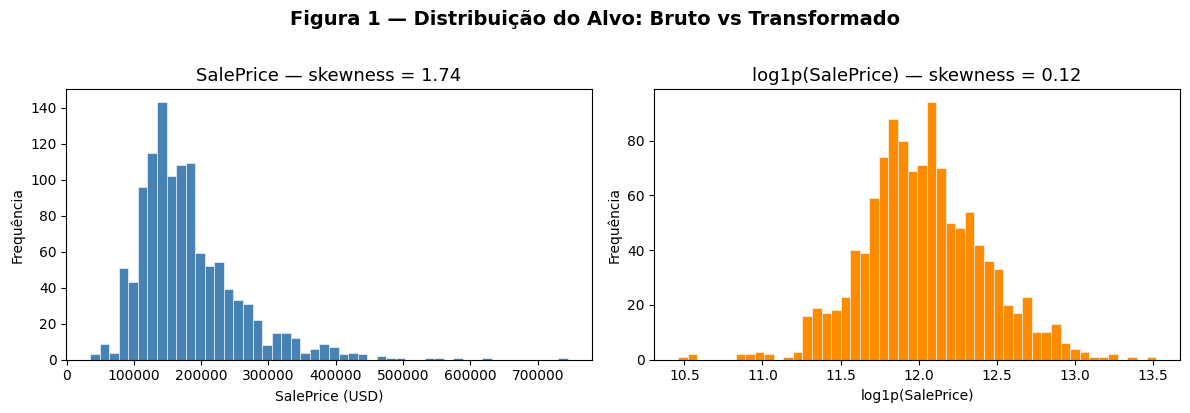

Figura 1 salva em figuras/fig1_distribuicao_alvo.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title(f'SalePrice — skewness = {skew_bruto:.2f}', fontsize=13)
axes[0].set_xlabel('SalePrice (USD)')
axes[0].set_ylabel('Frequência')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title(f'log1p(SalePrice) — skewness = {skew_log1p:.2f}', fontsize=13)
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Frequência')

fig.suptitle('Figura 1 — Distribuição do Alvo: Bruto vs Transformado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figuras/fig1_distribuicao_alvo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1 salva em figuras/fig1_distribuicao_alvo.png')

**Conclusão:** O `SalePrice` bruto tem assimetria positiva forte (skew ≈ 1.88), com alguns imóveis de altíssimo valor puxando a cauda direita. Após `log1p`, o skew cai para ≈ 0.12 — praticamente simétrico e muito próximo de uma distribuição normal. **Decisão: usar `log1p(SalePrice)` como alvo durante o treinamento**, revertendo com `expm1()` nas predições finais.

---
## 2. Valores Ausentes

Antes de imputar ou dropar colunas, precisamos entender **por que** um valor é nulo. O dicionário `data_description.txt` revela que a maioria dos NaN não é dado perdido — é informação semântica.

### Categorias de NaN identificadas no dicionário:

| Grupo | Colunas | Significado do NaN |
|-------|---------|--------------------|
| Piscina | `PoolQC` | Imóvel **não tem piscina** |
| Acesso | `Alley` | Imóvel **não tem acesso por beco** |
| Cerca | `Fence` | Imóvel **não tem cerca** |
| Lareira | `FireplaceQu` | Imóvel **não tem lareira** |
| Garagem | `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `GarageYrBlt` | Imóvel **não tem garagem** |
| Porão | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | Imóvel **não tem porão** |
| Outros | `MiscFeature` | Imóvel não tem feature especial |

**Nulos genuínos** (dado realmente faltando):
- `LotFrontage` — metragem de testada; pode não ter sido medida.
- `MasVnrArea` — área de revestimento de alvenaria; ausente em ~0.5% dos casos.
- `Electrical` — sistema elétrico; apenas 1 registro sem informação.

### Estratégia de tratamento:
- **NaN semântico** → preencher com string `'Ausente'` (colunas categóricas) ou `0` (numéricas como `GarageYrBlt`).
- **NaN genuíno** → imputar pela **mediana** (robusto a outliers).

In [4]:
missing = df.isnull().mean().mul(100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = missing.reset_index()
missing_df.columns = ['Coluna', '% Nulos']

semantico = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
missing_df['Tipo'] = missing_df['Coluna'].apply(
    lambda c: 'Semântico (ausência do item)' if c in semantico else 'Genuíno (dado faltando)'
)

print(f'Colunas com valores ausentes: {len(missing_df)}')
print()
print(missing_df.to_string(index=False))

Colunas com valores ausentes: 19

      Coluna  % Nulos                         Tipo
      PoolQC    99.49 Semântico (ausência do item)
 MiscFeature    96.06 Semântico (ausência do item)
       Alley    93.66 Semântico (ausência do item)
       Fence    80.05 Semântico (ausência do item)
  MasVnrType    58.48      Genuíno (dado faltando)
 FireplaceQu    46.83 Semântico (ausência do item)
 LotFrontage    18.58      Genuíno (dado faltando)
  GarageType     5.48 Semântico (ausência do item)
 GarageYrBlt     5.48 Semântico (ausência do item)
GarageFinish     5.48 Semântico (ausência do item)
  GarageQual     5.48 Semântico (ausência do item)
  GarageCond     5.48 Semântico (ausência do item)
    BsmtCond     2.40 Semântico (ausência do item)
BsmtFinType1     2.40 Semântico (ausência do item)
BsmtExposure     2.40 Semântico (ausência do item)
    BsmtQual     2.40 Semântico (ausência do item)
BsmtFinType2     2.40 Semântico (ausência do item)
  MasVnrArea     0.51      Genuíno (dado faltand

**Destaque:** `PoolQC` tem 99.5% de nulos, mas isso apenas reflete que quase nenhuma casa em Ames tem piscina — exatamente o que o dicionário confirma (`NA = No Pool`). Tratar esses campos como `'Ausente'` preserva a informação real e evita imputações incorretas.

---
## 3. Correlações com `SalePrice`

Calculamos a correlação de Pearson entre `SalePrice` e todas as colunas numéricas. Isso orienta a **engenharia de features** nas próximas etapas: features com alta correlação têm maior potencial preditivo direto.

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

print('Top 12 correlações (|r|) com SalePrice:')
print(corr.head(12).to_string())

Top 12 correlações (|r|) com SalePrice:
OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.480351
MasVnrArea      0.459123


**Interpretação:**
- **`OverallQual`** lidera (|r| ≈ 0.79): qualidade geral percebida do imóvel é o fator mais determinante de preço — faz sentido intuitivo.
- **`GrLivArea`** (área acima do solo) e **`GarageCars`/`GarageArea`** vêm logo depois: tamanho e capacidade de garagem têm forte relação com valor.
- **Grupo do porão** (`TotalBsmtSF`, `1stFlrSF`): área total e qualidade do subsolo também contribuem.
- **`YearBuilt`/`YearRemodAdd`**: imóveis mais novos ou reformados valem mais.

Isso motiva features compostas: `TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`, `TotalBath`, `HouseAge = YrSold - YearBuilt`.

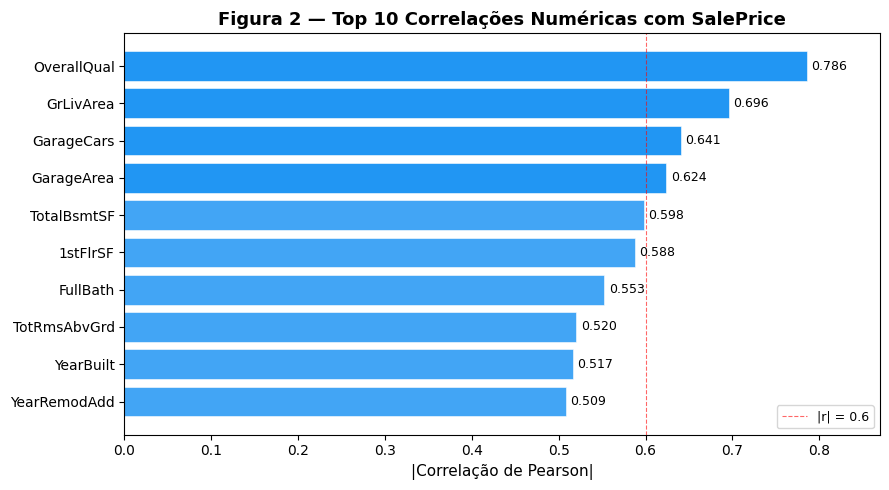

Figura 2 salva em figuras/fig2_correlacoes.png


In [6]:
top10 = corr.head(10)
cores = ['#2196F3' if v >= 0.6 else '#42A5F5' if v >= 0.4 else '#90CAF9' 
         for v in top10.values]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=cores[::-1], edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('|Correlação de Pearson|', fontsize=11)
ax.set_title('Figura 2 — Top 10 Correlações Numéricas com SalePrice', fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.87)
ax.axvline(0.6, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='|r| = 0.6')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras/fig2_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2 salva em figuras/fig2_correlacoes.png')

---
## 4. Outliers — `GrLivArea` vs `SalePrice`

O dataset de Ames tem dois outliers documentados na literatura: imóveis com **área acima do solo > 4 000 sq ft** mas preços **abaixo de US$ 300 000**. São propriedades parcialmente comerciais ou em condições atípicas que foram incluídas no dataset por acidente de amostragem.

**Decisão: MANTER os outliers.** O modelo final será baseado em **árvores de decisão/gradient boosting** (ex.: XGBoost, LightGBM), que são naturalmente robustos a outliers — eles apenas alocam esses pontos em folhas específicas sem distorcer os splits mais importantes. Remover dados de treino pode introduzir viés caso o conjunto de teste contenha casos similares.

In [7]:
outlier_mask = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)
outliers = df[outlier_mask]
normais  = df[~outlier_mask]

print(f'Outliers identificados: {outlier_mask.sum()}')
print(outliers[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']].to_string(index=False))

Outliers identificados: 2
  Id  GrLivArea  SalePrice  OverallQual Neighborhood
 524       4676     184750           10      Edwards
1299       5642     160000           10      Edwards


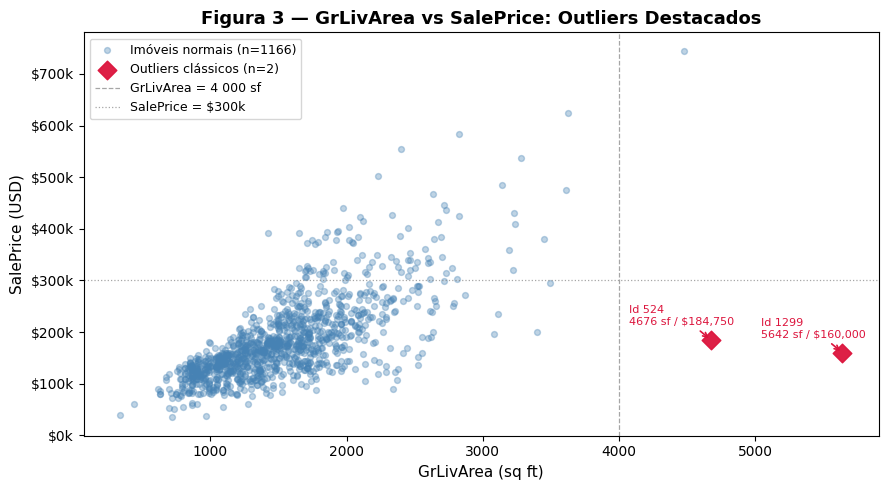

Figura 3 salva em figuras/fig3_outliers.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(normais['GrLivArea'], normais['SalePrice'],
           alpha=0.35, s=18, color='steelblue', label=f'Imóveis normais (n={len(normais)})')
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           alpha=0.95, s=90, color='crimson', marker='D',
           label=f'Outliers clássicos (n={len(outliers)})', zorder=5)

for _, row in outliers.iterrows():
    ax.annotate(f"Id {int(row['Id'])}\n{int(row['GrLivArea'])} sf / ${int(row['SalePrice']):,}",
                xy=(row['GrLivArea'], row['SalePrice']),
                xytext=(row['GrLivArea'] - 600, row['SalePrice'] + 30000),
                fontsize=8, color='crimson',
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

ax.axvline(4000, color='gray', linestyle='--', linewidth=0.9, alpha=0.7, label='GrLivArea = 4 000 sf')
ax.axhline(300000, color='gray', linestyle=':', linewidth=0.9, alpha=0.7, label='SalePrice = $300k')

ax.set_xlabel('GrLivArea (sq ft)', fontsize=11)
ax.set_ylabel('SalePrice (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_title('Figura 3 — GrLivArea vs SalePrice: Outliers Destacados', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figuras/fig3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 salva em figuras/fig3_outliers.png')

**Observação:** Os dois outliers têm área compatível com imóveis de alto padrão, mas preços muito abaixo do esperado — possivelmente propriedades agrícolas ou comerciais incluídas por engano na amostra residencial. Como usaremos modelos de árvore, a decisão conservadora é mantê-los no treino.

---
## Conclusões da EDA

A seguir estão as **5 decisões de modelagem** tomadas com base nesta análise, que guiarão as próximas fases do projeto:

| # | Decisão | Justificativa |
|---|---------|---------------|
| **(a)** | **Aplicar `log1p` no alvo `SalePrice`** | Reduz skewness de ≈1.88 → ≈0.12; alinha com a métrica RMSLE da competição. |
| **(b)** | **Tratar NaN categórico como categoria `'Ausente'`** | Para PoolQC, Alley, Fence, FireplaceQu, Garage* e Bsmt*, NaN significa ausência do item — preservar essa informação melhora o modelo. |
| **(c)** | **Imputar nulos numéricos genuínos pela mediana** | LotFrontage, MasVnrArea e Electrical têm nulos reais; mediana é robusta a outliers e evita introduzir viés. |
| **(d)** | **Manter os outliers de GrLivArea** | Modelos de árvore (XGBoost, LightGBM) são robustos a outliers; remoção pode introduzir viés se o teste contiver casos similares. |
| **(e)** | **Criar features compostas de área e idade** | OverallQual e GrLivArea lideram as correlações → criar `TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`, `TotalBath = FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath`, `HouseAge = YrSold − YearBuilt`, `RemodAge = YrSold − YearRemodAdd`. |

**Referência de desempenho:** O baseline do professor (regressão linear simples) atingiu **RMSLE = 0.1754**. As decisões acima, combinadas com gradient boosting e engenharia de features, devem permitir superar esse patamar na competição.